# Importing Librarires

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import cv2
import tensorflow
from tensorflow.keras import layers
from tensorflow.keras.layers import Conv2D, Dense
import kagglehub
import random
from PIL import Image
import warnings
warnings.filterwarnings("ignore")

In [2]:
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Path to dataset files: /kaggle/input/gtsrb-german-traffic-sign


In [3]:
current_dir=os.getcwd()

In [4]:
os.listdir(current_dir)

['.config', 'sample_data']

In [5]:
dataset_dir=Path(path)
classes=os.listdir(dataset_dir)
print("Classes",classes)

Classes ['Meta', 'meta', 'Meta.csv', 'Train.csv', 'Test.csv', 'Test', 'test', 'Train', 'train']


In [6]:
dataset_dir = Path(path)

# Point to the "Train" folder
train_dir = dataset_dir / "Train"

# List the class folders inside Train
classes = os.listdir(train_dir)
print("Training Classes:", classes)
print("Number of classes:", len(classes))

Training Classes: ['7', '17', '19', '22', '2', '35', '23', '10', '5', '36', '20', '27', '41', '39', '32', '25', '42', '8', '38', '12', '0', '31', '34', '18', '28', '16', '13', '26', '15', '3', '1', '30', '14', '4', '9', '21', '40', '6', '11', '37', '33', '29', '24']
Number of classes: 43


In [7]:
dataset_dir = Path(path)

# Point to the "Train" folder
train_dir = dataset_dir / "Train"
train_classes = os.listdir(train_dir)
print("Training Classes:", len(train_classes))

Training Classes: 43


In [8]:


train_images = tensorflow.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    labels="inferred",
    label_mode="categorical",
    image_size=(32, 32),
    batch_size=32
)

val_images = tensorflow.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    labels="inferred",
    label_mode="categorical",
    image_size=(32, 32),
    batch_size=32
)


# Check class names
print(train_images.class_names)


Found 39209 files belonging to 43 classes.
Using 31368 files for training.
Found 39209 files belonging to 43 classes.
Using 7841 files for validation.
['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']


In [9]:
dataset_dir = Path("/kaggle/input/gtsrb-german-traffic-sign")
labels_df = pd.read_csv(dataset_dir / "Test.csv")

test_images = [str(dataset_dir / row["Path"]) for _, row in labels_df.iterrows()]
test_labels = labels_df["ClassId"].tolist()

print("Number of test images:", len(test_images))
print("Number of test labels:", len(test_labels))
print("Sample:", test_images[0], "->", test_labels[0])


Number of test images: 12630
Number of test labels: 12630
Sample: /kaggle/input/gtsrb-german-traffic-sign/Test/00000.png -> 16


# Checking Sample Images

In [10]:
image_path=r"/kaggle/input/gtsrb-german-traffic-sign/Test/01302.png"

In [11]:

def show_image(image_path):
  img = Image.open(image_path)
  plt.imshow(img)
  plt.axis("off")
  return plt.show()


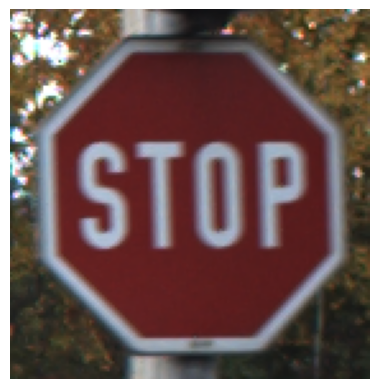

In [12]:
show_image(image_path)

In [13]:
def show_images(train_dir):
    train_dir = Path(train_dir)
    # get all image paths
    all_images = [train_dir/c/img for c in os.listdir(train_dir) for img in os.listdir(train_dir/c)]
    # pick 5
    sample_images = random.sample(all_images, 5)
    # plot
    plt.figure(figsize=(12, 6))
    for i, img_path in enumerate(sample_images):
        plt.subplot(1, 5, i+1)
        plt.imshow(plt.imread(img_path))
        plt.title(img_path.parent.name)
        plt.axis("off")
    plt.show()


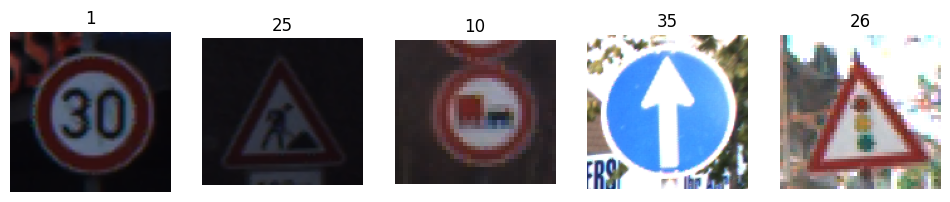

In [14]:
show_images(train_dir)

# CNN ARCHITECTURE

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout,BatchNormalization
model=Sequential()

model.add(Conv2D(32,kernel_size=(3,3),activation="relu",input_shape=(32,32,3)))
model.add(Conv2D(64,(3,3),activation="relu"))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.25))

model.add(Conv2D(128,kernel_size=(3,3),activation="relu"))
model.add(Conv2D(256,(3,3),activation="relu"))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(512,activation="relu"))
model.add(Dropout(0.25))
model.add(Dense(43,activation="softmax"))

In [16]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [17]:
history=model.fit(train_images,epochs=10,validation_data=val_images,verbose=1)

Epoch 1/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 113s 108ms/step - accuracy: 0.5635 - loss: 2.9479 - val_accuracy: 0.9690 - val_loss: 0.1121
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.9378 - loss: 0.2237 - val_accuracy: 0.9850 - val_loss: 0.0529
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.9567 - loss: 0.1590 - val_accuracy: 0.9884 - val_loss: 0.0460
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.9637 - loss: 0.1241 - val_accuracy: 0.9843 - val_loss: 0.0568
Epoch 5/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.9641 - loss: 0.1319 - val_accuracy: 0.9860 - val_loss: 0.0577
Epoch 6/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.9697 - loss: 0.1189 - val_accuracy: 0.9880 - val_loss: 0.0436
Epoch 7/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.9727 - loss: 0.0983 - val_accuracy: 0.9912 - val_loss: 0.0390
Epoch 8/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.9709 - loss: 0.1153 

In [18]:
def plot_accuracy_loss(history):
    plt.figure(figsize=(12,5))

    # Accuracy subplot
    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Train Accuracy", color="royalblue")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy", color="orange")
    plt.title("Model Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss subplot
    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Train Loss", color="red")
    plt.plot(history.history["val_loss"], label="Validation Loss", color="green")
    plt.title("Model Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()


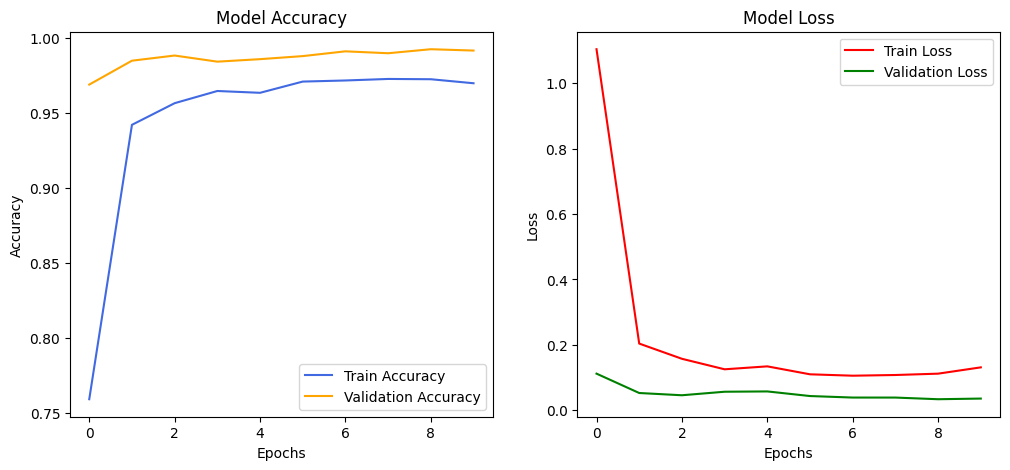

In [19]:
plot_accuracy_loss(history)

# Predictions

In [20]:
def preprocess_image(image_path):
  img=cv2.imread(image_path)
  img=cv2.resize(img,(32,32))
  img= np.expand_dims(img, axis=0)
  img=img/255.0
  return img

In [24]:
img = test_images[10]        # e.g. 'car.jpg'
img_path = img               # if it's already full path
# OR if you know folder separately:
img_path = os.path.join("path/to/test/folder", img)

img=preprocess_image(img_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step
Predicted class: 18 with confidence: 0.6520697


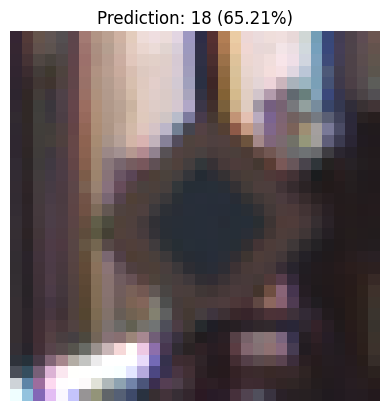

In [25]:
pred_probs = model.predict(img)   # probabilities
pred_class = np.argmax(pred_probs, axis=1)[0]  # index of max probability
pred_label = classes[pred_class]        # map index to class name

print("Predicted class:", pred_label, "with confidence:", pred_probs[0][pred_class])

plt.imshow(img[0])
plt.title(f"Prediction: {pred_label} ({pred_probs[0][pred_class]*100:.2f}%)")
plt.axis("off")
plt.show()

In [28]:
model.save("Traffic_Recognition_Model.h5")